## Ejemplos iniciales con OpenCV - Python
### Jupyter notebook

https://jupyter.readthedocs.io/en/latest/install.html

In [1]:

import numpy as np
import cv2 as cv
import sys

print("Python version %s / OpenCV version %s " %(sys.version,cv.__version__))

Python version 3.5.3 (default, Sep 27 2018, 17:25:39) 
[GCC 6.3.0 20170516] / OpenCV version 4.0.0 


In [12]:
# Lectura de un archivo de imagen. 
img_color=cv.imread("camino.tif")
# Las funciones reciben banderas (numeros enteros)
img_gray=cv.imread("camino.tif",cv.IMREAD_GRAYSCALE)
# Guardar la nueva imagen
cv.imwrite("nueva.jpg",img_gray)

# Las imagenes se representan en matrices de Numpy de forma [alto,ancho,n_canales], con un tipo de dato determinado
# (flotante,entero,booleano, etc.), por tanto se pueden utilizar todas las propiedades de Numpy.
H,W,C=img_color.shape
imtype=img_color.dtype
print("Imágen de tipo %s, alto=%d, ancho=%d, ncanales=%d" %(imtype,H,W,C))

Imágen de tipo uint8, alto=307, ancho=442, ncanales=3


### Graficación

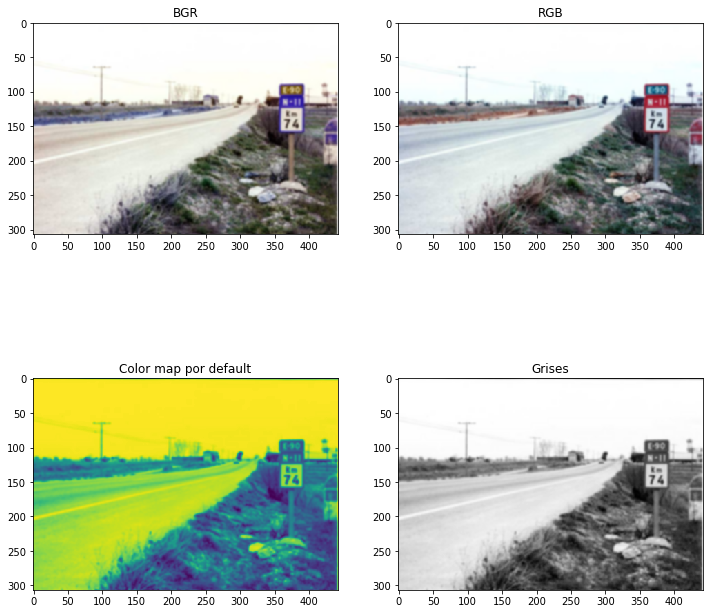

In [14]:
# Para graficar, se pueden utilizar las funciones de opencv o la librería matplotlib, que es mucho mas versatil para combinar diferentes tipos de gráficas. Tener en cuenta que OpenCV lee las imagenes en orden BGR mientras que matplotlib en RGB. 
from matplotlib import pyplot as plt

fig, ax = plt.subplots(nrows=2,ncols=2,figsize=(12,12)) # cuatro imagenes en una figura

# Por defecto, imshow toma imágenes HXCX3 como RGB
ax[0,0].imshow(img_color)
ax[0,0].set_title("BGR")
ax[0,1].imshow(img_color[:,:,::-1]) # invierte los canales, ::-1 indica que se recorre desde el ultimo elemento al primero
ax[0,1].set_title("RGB")

# Si es de un solo canal, y no se especifica nada mas, se dibuja una imagen con un mapa de color por defecto, asignando a cada nivel de gris un color RGB
ax[1,0].imshow(img_gray)
ax[1,0].set_title("Color map por default")
# para representar correctamente una imagen de grises, usar el mapa da color "gray" y explicitar el valor minimo y máximo de intensidad.
ax[1,1].imshow(img_gray,cmap="gray",vmin=0,vmax=255) # invierte los canales, ::-1 indica que se recorre desde el ultimo elemento al
ax[1,1].set_title("Grises")

plt.show()

### ROI y operaciones puntuales

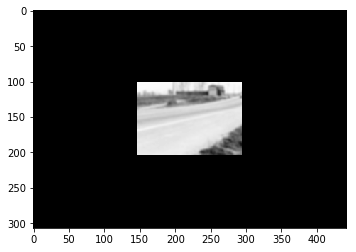

In [16]:
# Podemos generar una mascara binaria para operar con imágenes.
mask=np.zeros((H,W,C),dtype=imtype) # dtype: 'int8', bool, float, tener en cuenta el tipo de dato al realizar las operaciones
# O bien:
mask=img_gray.copy()
mask[:]=0
# Las imagenes son objetos y para hacer copias se debe tener en cuenta que el operador de asignación ("=") copia también el puntero al objeto.

# generamos una ROI con unos en la máscara
mask[int(H/3):int(2*H/3),int(W/3):int(2*W/3)]=255 # Máscara rectangular

# operación AND pixel a pixel
img_recorte=cv.bitwise_and(img_gray,mask)

plt.imshow(img_recorte,cmap="gray",vmin=0,vmax=255)
plt.show()

### Interfaces de comunicación en jupyter.
Función basada en eventos asociada al click sobre la imagen.

Instalación: https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [24]:
import ipywidgets as widgets
from ipywidgets import interact

def bright(x):
    #img_new=img_gray+x # tener en cuenta la profundidad en bits cuando se hacen operaciones aritméticas
    img_new=cv.add(img_gray,x)   
    plt.imshow(img_new,cmap="gray",vmin=0,vmax=255)
    plt.show()

interact(bright,x=widgets.IntSlider(min=-100,max=100,step=1,value=10))

interactive(children=(IntSlider(value=10, description='x', min=-100), Output()), _dom_classes=('widget-interac…

<function __main__.bright(x)>